# Step 8: Statistical Comparison — Best Model vs Naive Baseline
### DI 501 Term Project | Eda Yilmaz

**Goal:**  
Test whether the tuned Random Forest achieves statistically significantly lower prediction errors than the naive baseline, per cluster.

**Test:** Wilcoxon signed-rank test (non-parametric, paired)  
- Compare absolute errors of RF Tuned vs Naive for each observation  
- H₀: No difference in error distributions  
- H₁: RF Tuned has significantly lower errors  
- α = 0.05, one-sided  

**Why Wilcoxon:** Prediction errors are not normally distributed; paired non-parametric test is appropriate.

---

## 1. Load Data & Fit Best Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler

plt.rcParams['figure.dpi'] = 120

SELECTED_FEATURES = ['heat_stress_days', 'prec_gs']
TARGET            = 'detrended_yield'
CLUSTERS          = [0, 1, 2]
CLUSTER_COLORS    = {0: '#e07b39', 1: '#3b82c4', 2: '#5aad5a'}
ML_EXCLUDE        = ['BR', 'US']

df = pd.read_csv('./master_global_ml_dataset.csv').dropna(
    subset=SELECTED_FEATURES + [TARGET]
)
df = df[~df['country'].isin(ML_EXCLUDE)].copy()

print(f'ML training dataset: {len(df):,} obs | {df["country"].nunique()} countries')
print('Obs per cluster:')
print(df.groupby('cluster').size().to_string())

# ── Re-run GridSearchCV to find best params (same grid as Step 7) ────────────
print()
print('Running GridSearchCV to find best hyperparameters...')
scaler_gs = StandardScaler()
X_gs = scaler_gs.fit_transform(df[SELECTED_FEATURES].values)
y_gs = df[TARGET].values

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    {'max_depth': [2,3,4,5,6,8], 'min_samples_leaf': [5,10,20,50], 'min_samples_split': [5,10,20]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
dt_grid.fit(X_gs, y_gs)

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [50,100,200], 'max_depth': [3,5,8,None], 'min_samples_leaf': [5,10,20]},
    cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1, verbose=0
)
rf_grid.fit(X_gs, y_gs)

DT_BEST_PARAMS = dt_grid.best_params_
RF_BEST_PARAMS = rf_grid.best_params_

print(f'Best DT params: {DT_BEST_PARAMS}')
print(f'Best RF params: {RF_BEST_PARAMS}')

ML training dataset: 30,278 obs | 36 countries
Obs per cluster:
cluster
0     8754
1    20143
2     1381

Running GridSearchCV to find best hyperparameters...
Best DT params: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 5}
Best RF params: {'max_depth': 3, 'min_samples_leaf': 20, 'n_estimators': 200}


---
## 2. Generate Per-Observation Predictions (5-fold CV)

In [2]:
def get_cv_predictions(model, df, features, target, n_splits=5):
    """Returns array of out-of-sample predictions via 5-fold CV."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    X = df[features].values
    y = df[target].values
    all_preds = np.zeros(len(df))
    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train = y[train_idx]
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_test  = scaler.transform(X_test)
        model.fit(X_train, y_train)
        all_preds[test_idx] = model.predict(X_test)
    return all_preds

rf_tuned = RandomForestRegressor(random_state=42, **RF_BEST_PARAMS)
dt_tuned = DecisionTreeRegressor(random_state=42, **DT_BEST_PARAMS)

pred_df = df[['adm_id', 'country', 'cluster', 'yield', TARGET]].copy()
pred_df['y_pred_rf']    = get_cv_predictions(rf_tuned, df, SELECTED_FEATURES, TARGET)
pred_df['y_pred_dt']    = get_cv_predictions(dt_tuned, df, SELECTED_FEATURES, TARGET)
pred_df['y_pred_naive'] = 0.0

pred_df['ae_rf']    = np.abs(pred_df[TARGET] - pred_df['y_pred_rf'])
pred_df['ae_dt']    = np.abs(pred_df[TARGET] - pred_df['y_pred_dt'])
pred_df['ae_naive'] = np.abs(pred_df[TARGET] - pred_df['y_pred_naive'])

print(f'Predictions generated for {len(pred_df):,} observations.')
print()
print('Mean Absolute Error — overall:')
print(f'  Naive:    {pred_df["ae_naive"].mean():.4f} t/ha')
print(f'  DT Tuned: {pred_df["ae_dt"].mean():.4f} t/ha')
print(f'  RF Tuned: {pred_df["ae_rf"].mean():.4f} t/ha')

Predictions generated for 30,278 observations.

Mean Absolute Error — overall:
  Naive:    0.7423 t/ha
  DT Tuned: 0.7351 t/ha
  RF Tuned: 0.7314 t/ha


---
## 3. Wilcoxon Signed-Rank Test — Per Cluster

In [3]:
print('WILCOXON SIGNED-RANK TEST: Models vs Naive Baseline')
print('H0: No difference in absolute errors | H1: Model < Naive (one-sided)')
print('Significance level: alpha = 0.05')
print()

col_header = f'{"Cluster":<12} {"N":<8} {"MAE Naive":<12} {"MAE DT":<10} {"DT p":<10} {"MAE RF":<10} {"RF p":<10} {"DT result":<16} RF result'
print(col_header)
print('-' * 100)

results = []
for c in CLUSTERS:
    sub = pred_df[pred_df['cluster'] == c]
    ae_rf    = sub['ae_rf'].values
    ae_dt    = sub['ae_dt'].values
    ae_naive = sub['ae_naive'].values

    w_rf, p_rf = stats.wilcoxon(ae_rf, ae_naive, alternative='less')
    w_dt, p_dt = stats.wilcoxon(ae_dt, ae_naive, alternative='less')

    res_rf = 'SIGNIFICANT *' if p_rf < 0.05 else 'not significant'
    res_dt = 'SIGNIFICANT *' if p_dt < 0.05 else 'not significant'
    clabel = f'Cluster {c}'
    print(f'{clabel:<12} {len(sub):<8} {ae_naive.mean():<12.4f} {ae_dt.mean():<10.4f} {p_dt:<10.4f} {ae_rf.mean():<10.4f} {p_rf:<10.4f} {res_dt:<16} {res_rf}')

    results.append({
        'cluster': c, 'n': len(sub),
        'mae_naive': ae_naive.mean(),
        'mae_dt': ae_dt.mean(), 'p_dt': p_dt, 'sig_dt': p_dt < 0.05,
        'mae_rf': ae_rf.mean(), 'p_rf': p_rf, 'sig_rf': p_rf < 0.05,
    })

print()
sig_rf = sum(1 for r in results if r['sig_rf'])
sig_dt = sum(1 for r in results if r['sig_dt'])
print(f'RF Tuned significant in {sig_rf}/3 clusters')
print(f'DT Tuned significant in {sig_dt}/3 clusters')
print()
print('* p < 0.05 — model significantly outperforms naive baseline')

WILCOXON SIGNED-RANK TEST: Models vs Naive Baseline
H0: No difference in absolute errors | H1: Model < Naive (one-sided)
Significance level: alpha = 0.05

Cluster      N        MAE Naive    MAE DT     DT p       MAE RF     RF p       DT result        RF result
----------------------------------------------------------------------------------------------------
Cluster 0    8754     0.8290       0.8089     0.0000     0.8033     0.0000     SIGNIFICANT *    SIGNIFICANT *
Cluster 1    20143    0.7276       0.7229     0.0001     0.7195     0.0000     SIGNIFICANT *    SIGNIFICANT *
Cluster 2    1381     0.4061       0.4459     1.0000     0.4482     1.0000     not significant  not significant

RF Tuned significant in 2/3 clusters
DT Tuned significant in 2/3 clusters

* p < 0.05 — model significantly outperforms naive baseline


---
## 4. Visualisation — Error Distribution by Cluster

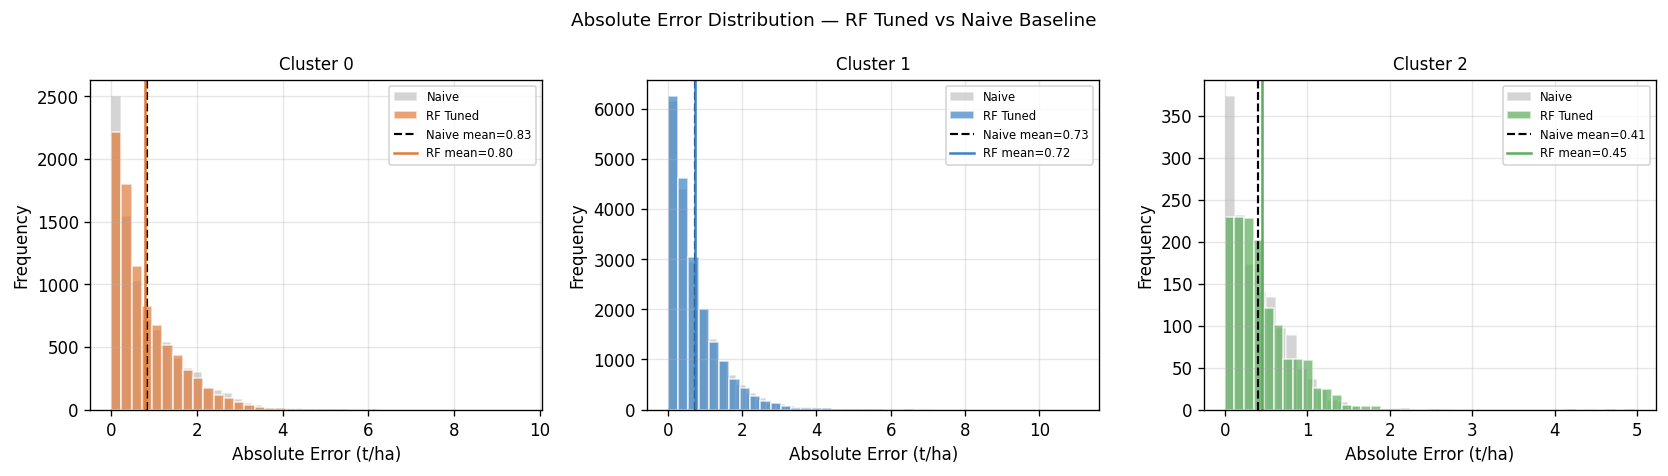

Saved: fig_error_distribution.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, c in zip(axes, CLUSTERS):
    sub = pred_df[pred_df['cluster'] == c]
    ax.hist(sub['ae_naive'], bins=40, alpha=0.5, color='#aaaaaa', label='Naive', edgecolor='white')
    ax.hist(sub['ae_rf'],    bins=40, alpha=0.7, color=CLUSTER_COLORS[c], label='RF Tuned', edgecolor='white')
    ax.axvline(sub['ae_naive'].mean(), color='black',          linestyle='--', linewidth=1.3, label=f'Naive mean={sub["ae_naive"].mean():.2f}')
    ax.axvline(sub['ae_rf'].mean(),    color=CLUSTER_COLORS[c], linestyle='-',  linewidth=1.5, label=f'RF mean={sub["ae_rf"].mean():.2f}')
    ax.set_title(f'Cluster {c}', fontsize=10)
    ax.set_xlabel('Absolute Error (t/ha)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Absolute Error Distribution — RF Tuned vs Naive Baseline', fontsize=11)
plt.tight_layout()
plt.savefig('./fig_error_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('Saved: fig_error_distribution.png')

---
## 5. Summary

In [5]:
print('STATISTICAL COMPARISON SUMMARY')
print()
for r in results:
    c = r['cluster']
    imp_rf = ((r['mae_naive'] - r['mae_rf']) / r['mae_naive']) * 100
    imp_dt = ((r['mae_naive'] - r['mae_dt']) / r['mae_naive']) * 100
    sig_rf = 'YES (p<0.05)' if r['sig_rf'] else 'NO'
    sig_dt = 'YES (p<0.05)' if r['sig_dt'] else 'NO'
    print(f'  Cluster {c}:')
    print(f'    DT: MAE improvement = {imp_dt:.1f}% | Significant: {sig_dt}')
    print(f'    RF: MAE improvement = {imp_rf:.1f}% | Significant: {sig_rf}')
print()
print('Interpretation:')
print('  Clusters where models significantly outperform naive: climate stress')
print('  features (heat_stress_days, prec_gs) carry real predictive signal.')
print()
print('  Clusters where difference is NOT significant: other factors dominate')
print('  yield variability (soil, varieties, management, irrigation).')
print()
print('Next step: Step 8b — Compare Koppen vs Data-Driven Cluster results')

STATISTICAL COMPARISON SUMMARY

  Cluster 0:
    DT: MAE improvement = 2.4% | Significant: YES (p<0.05)
    RF: MAE improvement = 3.1% | Significant: YES (p<0.05)
  Cluster 1:
    DT: MAE improvement = 0.6% | Significant: YES (p<0.05)
    RF: MAE improvement = 1.1% | Significant: YES (p<0.05)
  Cluster 2:
    DT: MAE improvement = -9.8% | Significant: NO
    RF: MAE improvement = -10.4% | Significant: NO

Interpretation:
  Clusters where models significantly outperform naive: climate stress
  features (heat_stress_days, prec_gs) carry real predictive signal.

  Clusters where difference is NOT significant: other factors dominate
  yield variability (soil, varieties, management, irrigation).

Next step: Step 8b — Compare Koppen vs Data-Driven Cluster results
